In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

dataset_path = "/content/drive/MyDrive/brand_dataset"

print("Dataset exists:", os.path.exists(dataset_path))
print("Folders:", os.listdir(dataset_path))

Dataset exists: True
Folders: ['camry', 'patrol', 'hilux', 'accent', 'elentra']


In [5]:
import os
import shutil
import random
from glob import glob

random.seed(42)

source_dir = "/content/drive/MyDrive/brand_dataset"
split_dir = "/content/brand_dataset_split"

classes = ["accent", "camry", "elentra", "hilux", "patrol"]

# حذف المجلد إذا كان موجود من قبل
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

# إنشاء المجلدات
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, split, cls), exist_ok=True)

# الامتدادات المسموحة
image_exts = ["*.jpg", "*.jpeg", "*.png", "*.webp"]

for cls in classes:
    cls_path = os.path.join(source_dir, cls)

    images = []
    for ext in image_exts:
        images.extend(glob(os.path.join(cls_path, ext)))

    random.shuffle(images)

    total = len(images)
    train_end = int(total * 0.70)
    val_end = int(total * 0.85)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(img, os.path.join(split_dir, "train", cls, os.path.basename(img)))

    for img in val_imgs:
        shutil.copy(img, os.path.join(split_dir, "val", cls, os.path.basename(img)))

    for img in test_imgs:
        shutil.copy(img, os.path.join(split_dir, "test", cls, os.path.basename(img)))

    print(f"{cls}: total={total}, train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

print("\nDone splitting dataset.")
print("New dataset path:", split_dir)

accent: total=964, train=674, val=145, test=145
camry: total=2246, train=1572, val=337, test=337
elentra: total=1569, train=1098, val=235, test=236
hilux: total=435, train=304, val=65, test=66
patrol: total=701, train=490, val=105, test=106

Done splitting dataset.
New dataset path: /content/brand_dataset_split


In [6]:
!pip install -q ultralytics

In [7]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA H100 80GB HBM3


In [8]:
from ultralytics import YOLO

# مودل تصنيف جاهز مبدئيًا
model = YOLO("yolov8n-cls.pt")

results = model.train(
    data="/content/brand_dataset_split",
    epochs=50,
    imgsz=224,
    batch=32,
    device=0,
    project="/content/car_brand_training",
    name="exp1"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brand_dataset_split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs

In [9]:
from ultralytics import YOLO

best_model_path = "/content/car_brand_training/exp1/weights/best.pt"
model = YOLO(best_model_path)

metrics = model.val(data="/content/brand_dataset_split", split="test")
print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,441,285 parameters, 0 gradients, 3.3 GFLOPs
train: /content/brand_dataset_split/train... found 4138 images in 5 classes ✅ 
val: /content/brand_dataset_split/val... found 887 images in 5 classes ✅ 
test: /content/brand_dataset_split/test... found 890 images in 5 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3229.6±1368.3 MB/s, size: 203.0 KB)
test: Scanning /content/brand_dataset_split/test... 890 images, 0 corrupt: 100% ━━━━━━━━━━━━ 890/890 4.8Kit/s 0.2s
test: /content/brand_dataset_split/test/camry/camry-1193577773.jpg: corrupt JPEG restored and saved
test: New cache created: /content/brand_dataset_split/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 56/56 22.5it/s 2.5s
                   all      0.983          1
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results sav

Exception in thread Thread-54 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d23716f6030>
curves: []
curves_results: []
fitness: 0.9915730357170105
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.983146071434021, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9915730357170105}
save_dir: PosixPath('/content/runs/classify/val')
speed: {'preprocess': 0.06383962808991128, 'inference': 0.20244416179729227, 'loss': 0.00048165056183136303, 'postprocess': 0.0005439247189223239}
top1: 0.983146071434021
top5: 1.0


Saving WhatsApp Image 2026-04-04 at 10.50.30 PM.jpeg to WhatsApp Image 2026-04-04 at 10.50.30 PM.jpeg

image 1/1 /content/WhatsApp Image 2026-04-04 at 10.50.30 PM.jpeg: 224x224 camry 1.00, elentra 0.00, hilux 0.00, accent 0.00, patrol 0.00, 2.2ms
Speed: 13.3ms preprocess, 2.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


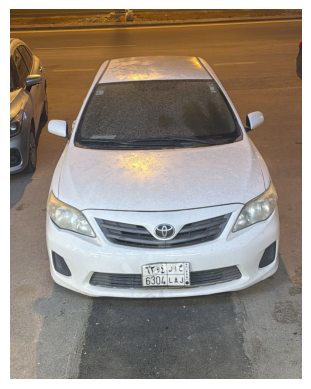

Predicted Car Model : camry
Predicted Brand     : Toyota
Confidence          : 99.97 %


In [10]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# تحميل أفضل مودل
best_model_path = "/content/car_brand_training/exp1/weights/best.pt"
model = YOLO(best_model_path)

# خريطة البراند
brand_map = {
    "accent": "Hyundai",
    "elentra": "Hyundai",
    "camry": "Toyota",
    "hilux": "Toyota",
    "patrol": "Nissan"
}

# ارفع صورة
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# تنبؤ
results = model.predict(source=image_path, imgsz=224)

# استخراج النتيجة
probs = results[0].probs
class_id = int(probs.top1)
class_name = results[0].names[class_id]
confidence = float(probs.top1conf)

brand_name = brand_map.get(class_name, "Unknown")

# عرض الصورة
img = Image.open(image_path)
plt.imshow(img)
plt.axis("off")
plt.show()

print("Predicted Car Model :", class_name)
print("Predicted Brand     :", brand_name)
print("Confidence          :", round(confidence * 100, 2), "%")

In [11]:
from google.colab import files

files.download('/content/car_brand_training/exp1/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>